x402 Protocol: Is the Volume Real?
A simple data-driven analysis of organic vs. gamed activity on x402.

Data: Artemis/Dune daily aggregates (May 2025 - Apr 2026)
Author: Paul | Shoal Research

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings("ignore")

In [34]:
BG = "#0D1117"
GRID = "#21262D"
TEXT = "#E6EDF3"
GREEN = "#00E5A0"
RED = "#FF6B4A"
PURPLE = "#7B68EE"
YELLOW = "#FFD93D"
BLUE = "#00BFFF"
MUTED = "#888888"
CARD_BG = "#161B22"

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "font.size": 10,
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.grid": True, "grid.color": GRID, "grid.alpha": 0.3,
})

In [35]:
avg = pd.read_csv(
    "/content/x402 avg tx size vs gamed % (latest) .csv",
    parse_dates=["DateTime"], encoding="utf-8-sig",
)
avg.columns = ["date", "avg_tx_size", "pct_gamed"]

vol = pd.read_csv(
    "/content/x402 daily txs + daily volume (latest).csv",
    parse_dates=["DateTime"], encoding="utf-8-sig",
)
vol.columns = ["date", "tx_count", "daily_volume"]

df = avg.merge(vol, on="date")
df = df[df["date"] >= "2025-05-06"].reset_index(drop=True)
df = df[df["avg_tx_size"] > 0].reset_index(drop=True)

df["gamed_volume"] = df["daily_volume"] * df["pct_gamed"]
df["organic_volume"] = df["daily_volume"] * (1 - df["pct_gamed"])
df["pct_gamed_pct"] = df["pct_gamed"] * 100
df["gamed_ma14"] = df["pct_gamed_pct"].rolling(14).mean()
df["avg_tx_ma14"] = df["avg_tx_size"].rolling(14).mean()

total_vol = df["daily_volume"].sum()
total_gamed = df["gamed_volume"].sum()
total_organic = total_vol - total_gamed

In [37]:
sorted_g = df["gamed_volume"].sort_values(ascending=False).reset_index(drop=True)
cum = sorted_g.cumsum() / sorted_g.sum()
top50_days = int(np.searchsorted(cum.values, 0.50)) + 1

last30 = df[df["date"] >= df["date"].max() - pd.Timedelta(days=30)]
last30_gamed_pct = last30["pct_gamed_pct"].mean()
last30_avg_tx = last30["avg_tx_size"].mean()
last30_vol = last30["daily_volume"].mean()

print(f"x402 Dataset: {df.date.min().date()} to {df.date.max().date()}")
print(f"Total volume: ${total_vol:,.0f}")
print(f"Gamed: ${total_gamed:,.0f} ({total_gamed/total_vol*100:.1f}%)")
print(f"Organic: ${total_organic:,.0f} ({total_organic/total_vol*100:.1f}%)")

x402 Dataset: 2025-05-09 to 2026-04-13
Total volume: $108,487,543
Gamed: $42,414,762 (39.1%)
Organic: $66,072,781 (60.9%)


(0.0, 115.0)

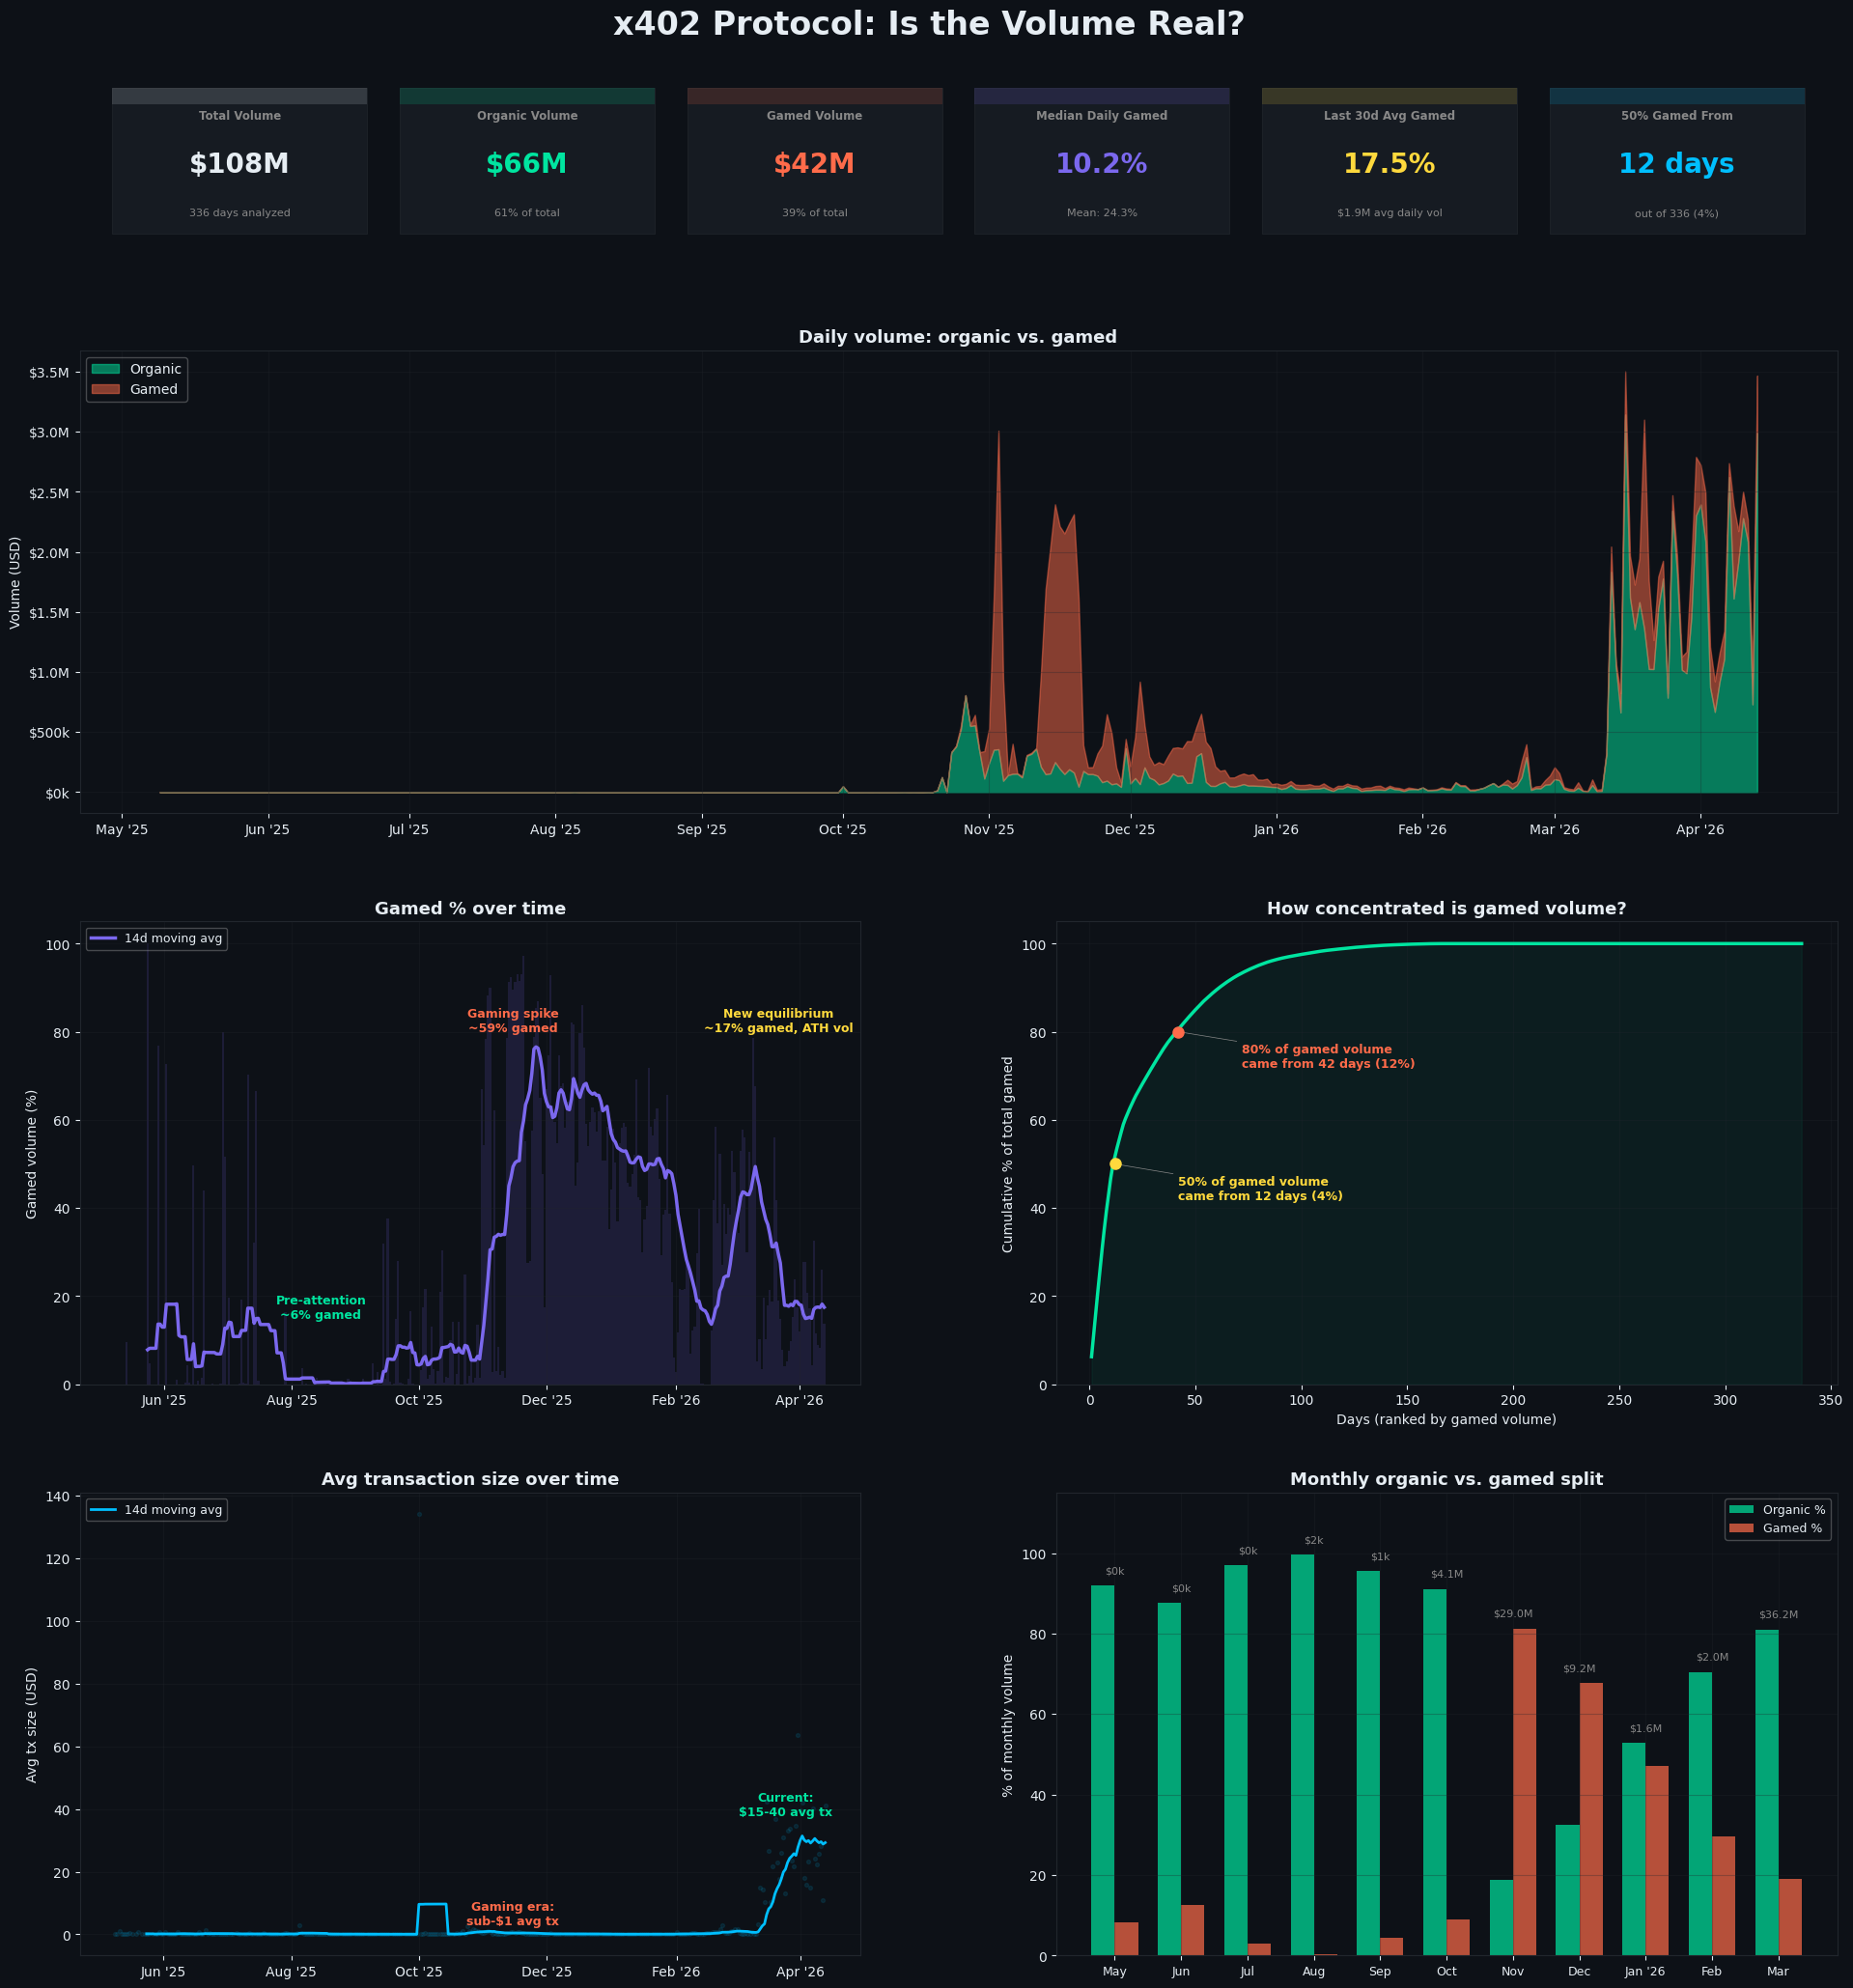

In [38]:
fig = plt.figure(figsize=(20, 21))
fig.suptitle(
    "x402 Protocol: Is the Volume Real?",
    fontsize=24, fontweight="bold", y=0.99,
)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.28, wspace=0.25,
                       top=0.955, bottom=0.03, left=0.06, right=0.97,
                       height_ratios=[0.35, 1, 1, 1])


# ── Row 0: Stat counter cards ──
ax_stats = fig.add_subplot(gs[0, :])
ax_stats.set_xlim(0, 1)
ax_stats.set_ylim(0, 1)
ax_stats.axis("off")

cards = [
    {"label": "Total Volume",     "value": f"${total_vol/1e6:.0f}M",           "sub": f"{len(df)} days analyzed",                  "color": TEXT},
    {"label": "Organic Volume",   "value": f"${total_organic/1e6:.0f}M",       "sub": f"{total_organic/total_vol*100:.0f}% of total",  "color": GREEN},
    {"label": "Gamed Volume",     "value": f"${total_gamed/1e6:.0f}M",         "sub": f"{total_gamed/total_vol*100:.0f}% of total",    "color": RED},
    {"label": "Median Daily Gamed","value": f"{df.pct_gamed_pct.median():.1f}%","sub": f"Mean: {df.pct_gamed_pct.mean():.1f}%",        "color": PURPLE},
    {"label": "Last 30d Avg Gamed","value": f"{last30_gamed_pct:.1f}%",         "sub": f"${last30_vol/1e6:.1f}M avg daily vol",        "color": YELLOW},
    {"label": "50% Gamed From",   "value": f"{top50_days} days",               "sub": f"out of {len(df)} ({top50_days/len(df)*100:.0f}%)", "color": BLUE},
]

n = len(cards)
card_w = 0.145
gap = (1 - n * card_w) / (n + 1)

for i, card in enumerate(cards):
    x = gap + i * (card_w + gap)
    rect = plt.Rectangle((x, 0.05), card_w, 0.9, transform=ax_stats.transAxes,
                          facecolor=CARD_BG, edgecolor=GRID, linewidth=0.5,
                          clip_on=False, zorder=1)
    accent = plt.Rectangle((x, 0.85), card_w, 0.1, transform=ax_stats.transAxes,
                            facecolor=card["color"], alpha=0.15, clip_on=False, zorder=2)
    ax_stats.add_patch(rect)
    ax_stats.add_patch(accent)

    cx = x + card_w / 2
    ax_stats.text(cx, 0.78, card["label"], transform=ax_stats.transAxes,
                  ha="center", va="center", fontsize=8.5, color=MUTED, fontweight="bold")
    ax_stats.text(cx, 0.48, card["value"], transform=ax_stats.transAxes,
                  ha="center", va="center", fontsize=20, color=card["color"],
                  fontweight="bold")
    ax_stats.text(cx, 0.18, card["sub"], transform=ax_stats.transAxes,
                  ha="center", va="center", fontsize=8, color=MUTED)


#Volume composition
ax = fig.add_subplot(gs[1, :])
ax.fill_between(df["date"], 0, df["organic_volume"],
                color=GREEN, alpha=0.5, label="Organic")
ax.fill_between(df["date"], df["organic_volume"],
                df["organic_volume"] + df["gamed_volume"],
                color=RED, alpha=0.5, label="Gamed")
ax.set_title("Daily volume: organic vs. gamed")
ax.set_ylabel("Volume (USD)")
ax.legend(framealpha=0.3, loc="upper left", fontsize=10)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}k"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))


# Gamed % over time
ax = fig.add_subplot(gs[2, 0])
ax.bar(df["date"], df["pct_gamed_pct"], color=PURPLE, alpha=0.15, width=1)
m14 = df["gamed_ma14"].notna()
ax.plot(df.loc[m14, "date"], df.loc[m14, "gamed_ma14"],
        color=PURPLE, linewidth=2.5, label="14d moving avg")

ax.annotate("Pre-attention\n~6% gamed",
            xy=(pd.Timestamp("2025-08-15"), 15),
            fontsize=9, color=GREEN, ha="center", fontweight="bold")
ax.annotate("Gaming spike\n~59% gamed",
            xy=(pd.Timestamp("2025-11-15"), 80),
            fontsize=9, color=RED, ha="center", fontweight="bold")
ax.annotate("New equilibrium\n~17% gamed, ATH vol",
            xy=(pd.Timestamp("2026-03-22"), 80),
            fontsize=9, color=YELLOW, ha="center", fontweight="bold")

ax.set_title("Gamed % over time")
ax.set_ylabel("Gamed volume (%)")
ax.legend(framealpha=0.3, loc="upper left", fontsize=9)
ax.set_ylim(0, 105)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))


# Concentration curve
ax = fig.add_subplot(gs[2, 1])
sorted_gamed = df["gamed_volume"].sort_values(ascending=False).reset_index(drop=True)
cum_pct = sorted_gamed.cumsum() / sorted_gamed.sum() * 100
ax.plot(range(1, len(cum_pct) + 1), cum_pct.values, color=GREEN, linewidth=2.5)
ax.fill_between(range(1, len(cum_pct) + 1), cum_pct.values, alpha=0.06, color=GREEN)

for thresh, color in [(50, YELLOW), (80, RED)]:
    idx = int(np.searchsorted(cum_pct.values, thresh)) + 1
    pct_days = idx / len(df) * 100
    ax.plot(idx, thresh, "o", color=color, markersize=8, zorder=5)
    ax.annotate(
        f"{thresh}% of gamed volume\ncame from {idx} days ({pct_days:.0f}%)",
        xy=(idx, thresh), xytext=(idx + 30, thresh - 8),
        fontsize=9, color=color, fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.5),
    )

ax.set_title("How concentrated is gamed volume?")
ax.set_xlabel("Days (ranked by gamed volume)")
ax.set_ylabel("Cumulative % of total gamed")
ax.set_ylim(0, 105)


# Avg transaction size
ax = fig.add_subplot(gs[3, 0])
m14a = df["avg_tx_ma14"].notna()
ax.plot(df.loc[m14a, "date"], df.loc[m14a, "avg_tx_ma14"],
        color=BLUE, linewidth=2, label="14d moving avg")
ax.scatter(df["date"], df["avg_tx_size"], color=BLUE, alpha=0.1, s=8)

ax.annotate("Gaming era:\nsub-$1 avg tx",
            xy=(pd.Timestamp("2025-11-15"), 3), fontsize=9,
            color=RED, ha="center", fontweight="bold")
ax.annotate("Current:\n$15-40 avg tx",
            xy=(pd.Timestamp("2026-03-25"), 38), fontsize=9,
            color=GREEN, ha="center", fontweight="bold")

ax.set_title("Avg transaction size over time")
ax.set_ylabel("Avg tx size (USD)")
ax.legend(framealpha=0.3, fontsize=9, loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))


# Monthly organic vs gamed
ax = fig.add_subplot(gs[3, 1])
monthly = df.set_index("date").resample("MS").agg(
    vol=("daily_volume", "sum"),
    gamed_vol=("gamed_volume", "sum"),
    organic_vol=("organic_volume", "sum"),
    days=("daily_volume", "count"),
)
monthly["pct_gamed"] = monthly["gamed_vol"] / monthly["vol"] * 100
monthly["pct_organic"] = monthly["organic_vol"] / monthly["vol"] * 100
monthly = monthly[monthly["days"] >= 15]

x = np.arange(len(monthly))
w = 0.35
ax.bar(x - w/2, monthly["pct_organic"], w, color=GREEN, alpha=0.7, label="Organic %")
ax.bar(x + w/2, monthly["pct_gamed"], w, color=RED, alpha=0.7, label="Gamed %")

for i, (_, row) in enumerate(monthly.iterrows()):
    v = row["vol"]
    label = f"${v/1e6:.1f}M" if v >= 1e6 else f"${v/1e3:.0f}k"
    ax.text(i, max(row["pct_organic"], row["pct_gamed"]) + 3,
            label, ha="center", fontsize=8, color=MUTED)

ax.set_xticks(x)
ax.set_xticklabels(
    [d.strftime("%b") if d.month != 1 else d.strftime("%b '%y") for d in monthly.index],
    fontsize=9,
)
ax.set_title("Monthly organic vs. gamed split")
ax.set_ylabel("% of monthly volume")
ax.legend(framealpha=0.3, fontsize=9)
ax.set_ylim(0, 115)
